In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier

from src.data_preprocessing import load_and_clean_data
from src.feature_engineering import get_preprocessor, encode_target
from src.model_training import train_model
from src.evaluation import evaluate_model

In [2]:
RANDOM_STATE = 42

data_path = "data/raw/synthetic_food_dataset_imbalanced.csv"

df = load_and_clean_data(data_path)
df.head()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,197.570043,dinner,fried,False,False,Pizza
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,103.833510,snack,raw,False,True,Ice Cream
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,198.989367,snack,raw,False,False,Burger
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,135.714202,lunch,fried,False,True,Sushi
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,73.019474,snack,baked,False,False,Donut


In [3]:
X = df.drop("Food_Name", axis=1)
y = df["Food_Name"]

y_encoded, label_encoder = encode_target(y)

numerical_features = [
    "Calories","Protein","Fat","Carbs","Sugar","Fiber",
    "Sodium","Cholesterol","Glycemic_Index",
    "Water_Content","Serving_Size"
]

categorical_features = [
    "Meal_Type","Preparation_Method",
    "Is_Vegan","Is_Gluten_Free"
]

preprocessor = get_preprocessor(numerical_features, categorical_features)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=RANDOM_STATE
)

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=RANDOM_STATE)
}

results = {}
trained_models = {}

for name, model in models.items():
    trained_model = train_model(model, preprocessor, X_train, y_train)
    acc, y_pred = evaluate_model(trained_model, X_test, y_test, name)

    results[name] = acc
    trained_models[name] = trained_model

results


🔹 Logistic Regression
Accuracy: 0.9942418426103646
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       294
           1       0.98      0.99      0.99       237
           2       0.98      0.99      0.99       984
           3       1.00      1.00      1.00       891
           4       1.00      0.99      0.99       591
           5       1.00      1.00      1.00       792
           6       1.00      0.99      0.99      1180
           7       1.00      0.99      1.00       197
           8       0.99      1.00      1.00       396
           9       0.99      1.00      1.00       690

    accuracy                           0.99      6252
   macro avg       0.99      0.99      0.99      6252
weighted avg       0.99      0.99      0.99      6252


🔹 KNN
Accuracy: 0.9924824056301983
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       294
           1       0.98      0.99      0.98 

{'Logistic Regression': 0.9942418426103646,
 'KNN': 0.9924824056301983,
 'Decision Tree': 0.9881637875879719,
 'Random Forest': 0.9944017914267435,
 'SVM': 0.9945617402431222,
 'Gradient Boosting': 0.9948816378758797,
 'XGBoost': 0.9945617402431222}

In [6]:
best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [7]:
sample_input = pd.DataFrame([{
    "Calories": 250,
    "Protein": 30,
    "Fat": 5,
    "Carbs": 20,
    "Sugar": 3,
    "Fiber": 4,
    "Sodium": 400,
    "Cholesterol": 50,
    "Glycemic_Index": 45,
    "Water_Content": 60,
    "Serving_Size": 150,
    "Meal_Type": "Dinner",
    "Preparation_Method": "Grilled",
    "Is_Vegan": 0,
    "Is_Gluten_Free": 1
}])

pred_class = best_model.predict(sample_input)
pred_food = label_encoder.inverse_transform(pred_class)

print("Predicted Food:", pred_food[0])

Predicted Food: Sushi


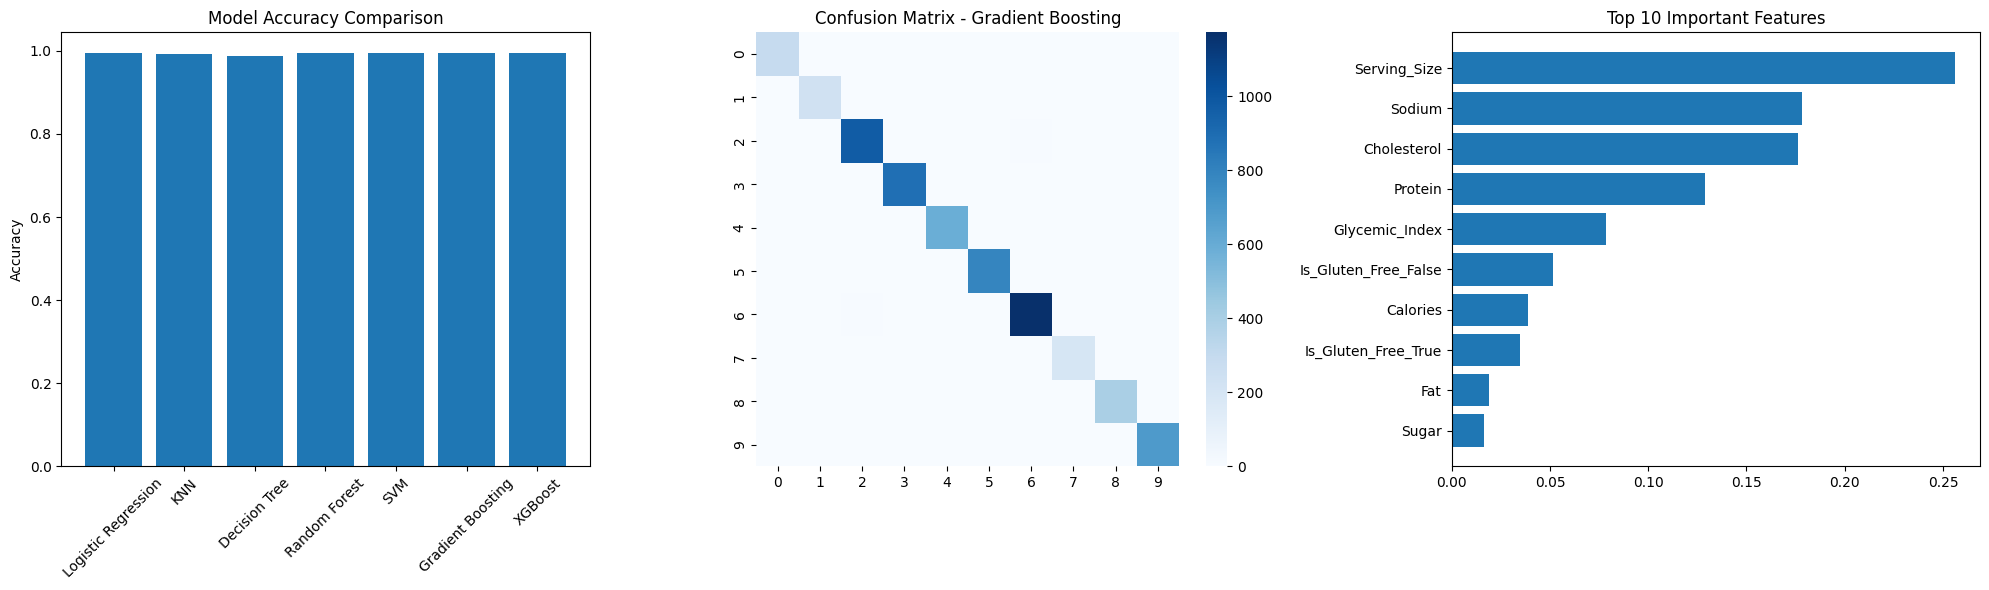

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Accuracy
axes[0].bar(results.keys(), results.values())
axes[0].set_title("Model Accuracy Comparison")
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel("Accuracy")

# Confusion Matrix
cm = confusion_matrix(y_test, best_model.predict(X_test))
sns.heatmap(cm, ax=axes[1], cmap="Blues")
axes[1].set_title(f"Confusion Matrix - {best_model_name}")

# Feature Importance
if best_model_name in ["Random Forest", "Gradient Boosting", "XGBoost"]:
    model = best_model.named_steps['model']
    preprocessor = best_model.named_steps['preprocessor']

    feature_names = (
        numerical_features +
        list(preprocessor.named_transformers_['cat']
             .named_steps['onehot']
             .get_feature_names_out(categorical_features))
    )

    importances = model.feature_importances_
    indices = np.argsort(importances)[-10:]

    axes[2].barh(range(len(indices)), importances[indices])
    axes[2].set_yticks(range(len(indices)))
    axes[2].set_yticklabels([feature_names[i] for i in indices])
    axes[2].set_title("Top 10 Important Features")

plt.tight_layout()
plt.show()